# 07 — Generalization: does the dual representation transfer?

**Experimental only.** `src/inference.py`, the frozen artifacts, the API, the dashboard and notebooks
01–06 are untouched. Nothing here is deployed.

## The question

Every result so far comes from **one station, one year**. Notebook 06 showed the dual representation
(16 features + `clim_short` + `acc_w4`) beats baseline on Safdarjung 2023 across the board. The open
question is whether that is *general sensor behaviour* or *Delhi 2023*.

## Data acquired for this experiment

Source: **NOAA NCEI Integrated Surface Database, global-hourly access**
`https://www.ncei.noaa.gov/data/global-hourly/access/{year}/{station}.csv`

Eight stations × two years (2023, 2024), filtered to **FM-12 synoptic** reports — the same 3-hourly
format the pipeline was built on. Cleaned copies are in `data/processed/stations/` with
`station_manifest.csv` recording every source URL.

| station id | name | lat | elev | environment |
|---|---|---|---|---|
| 42182099999 | Safdarjung (Delhi) | 28.58 | 215 m | inland N, semi-arid |
| 42101099999 | Patiala | 30.33 | 251 m | inland N, Punjab plains |
| 42410099999 | Guwahati | 26.11 | 49 m | NE, very wet |
| 42647099999 | Ahmedabad | 23.08 | 58 m | arid W |
| 42809099999 | Kolkata | 22.65 | 5 m | E delta, humid |
| 43003099999 | Mumbai | 19.09 | 11 m | W coastal |
| 43279099999 | Chennai | 12.99 | 16 m | SE coastal |
| 43371099999 | Thiruvananthapuram | 8.48 | 64 m | far S coastal tropical |

**One candidate was rejected on data quality, not convenience.** Bangalore (43295099999) is an
FM-12 station at 921 m and would have been the only high-altitude plateau contrast, but sea-level
pressure is present in **4 of 2828** observations. The pipeline requires SLP, so it cannot be used
without changing the feature set. It is excluded and named here rather than dropped silently.

Two station-ID guesses were wrong during discovery and are corrected: **42101099999 is Patiala, not
Leh.** No high-altitude station with usable SLP was found in this sweep.

## Leakage protocol — the critical part

| quantity | fitted on | never sees |
|---|---|---|
| Isolation Forest | training stations' **2023** features | any test-year or held-out-station row |
| **climatology** (drives `clim_dev`, `clim_short`, `acc_w4`) | the test station's own **2023** | the test year (2024), any fault label |
| `roll_std` NaN-fill constants | the test station's own **2023** | the test year |
| adaptive threshold | production algorithm, trailing 30-day, **past-only**, cold start | future rows, fault labels |
| injected faults | independent seeds per test series | seeds used anywhere in training |

**Why climatology is fitted per station rather than transferred.** A climatology is a physical
description of one location — Delhi's January mean is ~14 °C, Thiruvananthapuram's ~26 °C. Applying
one to the other does not test transfer, it manufactures a constant offset. Section 4 measures that
directly rather than asserting it. Fitting a station's climatology on its **own prior year** uses no
test-period information and is exactly what deployment at a new site would do.

In [1]:
import sys, os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from fault_injection import FaultSimulator, CHALLENGE_CONFIG, VARS
from inference import WeatherFaultDetector
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.width", 210); pd.set_option("display.max_columns", 60)

NOMINAL, ROLL, ROLLMIN = 3.0, "24h", 4
SEEDS = [71, 82, 93]                      # independent of every seed used previously
TRANSIENT = ["spike", "intermittent_spikes"]

MAN = pd.read_csv("../data/processed/stations/station_manifest.csv",
                  dtype={"station_id": str})   # keep the leading-zero-safe string id
STATIONS = (MAN.drop_duplicates("station_id")
            .set_index("station_id")[["name", "lat", "lon", "elevation_m", "environment"]])
print(STATIONS.to_string())

def load(sid, year):
    d = pd.read_csv(f"../data/processed/stations/{sid}_{year}.csv", parse_dates=["time"])
    return d[["time"] + VARS].reset_index(drop=True)

                           name    lat    lon  elevation_m              environment
station_id                                                                         
42182099999  Safdarjung (Delhi)  28.58  77.21          215      inland N, semi-arid
42101099999             Patiala  30.33  76.47          251  inland N, Punjab plains
42410099999            Guwahati  26.11  91.59           49             NE, very wet
42647099999           Ahmedabad  23.08  72.63           58                   arid W
42809099999             Kolkata  22.65  88.45            5           E delta, humid
43003099999              Mumbai  19.09  72.87           11                W coastal
43279099999             Chennai  12.99  80.18           16               SE coastal
43371099999  Thiruvananthapuram   8.48  76.95           64   far S coastal tropical


## 1. Feature pipeline with a pluggable climatology

`src/inference.py` carries Safdarjung's climatology baked in, so it cannot score another station.
The pipeline is reimplemented here with the climatology as a parameter — **and proved identical to
production** when handed the frozen one. Without that proof, nothing below would be comparable to
earlier notebooks.

In [2]:
def _steps(out):
    out["gap_hours"] = out.time.diff().dt.total_seconds() / 3600.0
    ok = out.gap_hours.eq(NOMINAL)
    for v in VARS:
        out[f"{v}_step"] = out[v].diff().where(ok)
    return out

def _rolling(out):
    s = out.set_index("time")
    for v in VARS:
        r = s[v].rolling(ROLL, center=True, min_periods=ROLLMIN)
        med = r.median().to_numpy(); sd = r.std().to_numpy()
        med = np.where(np.isnan(med), out[v].to_numpy(), med)
        out[f"{v}_roll_med"], out[f"{v}_roll_std"] = med, sd
        out[f"{v}_resid"] = out[v].to_numpy() - med
    return out

def fit_climatology(frame, half=7, min_periods=3):
    """(day-of-year x hour), +/-7-day smoothed, circular-padded. Notebook-02 algorithm."""
    clim = {}
    t = frame.copy(); t["date"] = t.time.dt.normalize(); t["hour"] = t.time.dt.hour.astype("int64")
    days = pd.date_range(t.date.min(), t.date.max(), freq="D"); w = 2 * half + 1
    for v in VARS:
        wide = t.pivot_table(index="date", columns="hour", values=v, aggfunc="mean").reindex(days)
        pad = pd.concat([wide.iloc[-half:], wide, wide.iloc[:half]], axis=0)
        r = pad.rolling(w, center=True, min_periods=min_periods)
        m = r.mean().iloc[half:len(pad) - half]; s = r.std().iloc[half:len(pad) - half]
        m.index, s.index = wide.index, wide.index
        floor = 0.10 * float(frame[v].std())
        mu, sd = m.stack(), s.stack().clip(lower=floor)
        idx = pd.MultiIndex.from_arrays([mu.index.get_level_values(0).dayofyear,
                                         mu.index.get_level_values(1).astype("int64")],
                                        names=["doy", "hour"])
        mu.index = idx; sd.index = idx
        clim[v] = {"mean": mu[~mu.index.duplicated()], "std": sd[~sd.index.duplicated()]}
    return clim

def fit_roll_fill(frame):
    f = _rolling(_steps(frame.copy()))
    return {f"{v}_roll_std": float(f[f"{v}_roll_std"].median()) for v in VARS}

FEATS16 = ["temp_c_step", "slp_hpa_step", "rh_pct_step",
           "temp_c_roll_std", "slp_hpa_roll_std", "rh_pct_roll_std",
           "temp_c_resid", "slp_hpa_resid", "rh_pct_resid",
           "temp_c_clim_dev", "slp_hpa_clim_dev", "rh_pct_clim_dev",
           "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
CD = [f"{v}_clim_dev" for v in VARS]

def build_features(frame, clim, fill):
    out = _steps(frame.copy())
    hour = out.time.dt.hour.to_numpy(); doy = out.time.dt.dayofyear.to_numpy()
    out["hour_sin"] = np.sin(2*np.pi*hour/24);  out["hour_cos"] = np.cos(2*np.pi*hour/24)
    out["doy_sin"]  = np.sin(2*np.pi*doy/365.25); out["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    out = _rolling(out)
    key = pd.MultiIndex.from_arrays([out.time.dt.dayofyear.astype("int64"),
                                     out.time.dt.hour.astype("int64")], names=["doy", "hour"])
    for v in VARS:
        mu = clim[v]["mean"].reindex(key).to_numpy(); sd = clim[v]["std"].reindex(key).to_numpy()
        out[f"{v}_clim_dev"] = (out[v].to_numpy() - mu) / sd
    for v in VARS:
        out[f"{v}_step"] = out[f"{v}_step"].fillna(0.0)
        c = f"{v}_roll_std"; out[c] = out[c].fillna(fill[c])
        out[f"{v}_clim_dev"] = out[f"{v}_clim_dev"].fillna(0.0)
        out[f"{v}_resid"] = out[f"{v}_resid"].fillna(0.0)
    short = out[CD].abs().max(axis=1).fillna(0.0)
    acc = pd.concat([out[c].rolling(4, min_periods=2).mean().abs() for c in CD],
                    axis=1).max(axis=1).fillna(0.0)
    out["clim_short"], out["acc_w4"] = short, acc
    return out

# ---- parity proof against production -------------------------------------------------
det = WeatherFaultDetector.load("../models")
_b = load("42182099999", 2023)
_prod = det._build_features(_b.copy())
_mine = build_features(_b.copy(), det.climatology, det.roll_std_fill)
dmax = max(np.abs(_mine[f].to_numpy() - _prod[f].to_numpy()).max() for f in FEATS16)
print(f"PARITY vs production pipeline (frozen climatology): max |diff| = {dmax:.2e}")
assert FEATS16 == list(det.features) and dmax < 1e-9
_mine2 = build_features(_b.copy(), fit_climatology(_b), fit_roll_fill(_b))
d2 = max(np.abs(_mine2[f].to_numpy() - _prod[f].to_numpy()).max() for f in FEATS16)
print(f"climatology refitted from the same data:          max |diff| = {d2:.2e}")
print("-> the multi-station pipeline is the production pipeline with the climatology exposed.")

PARITY vs production pipeline (frozen climatology): max |diff| = 0.00e+00
climatology refitted from the same data:          max |diff| = 1.74e-13
-> the multi-station pipeline is the production pipeline with the climatology exposed.


## 2. Station map and climate contrast

The point of this experiment is that these stations are genuinely different. If they were not, a
cross-station result would prove nothing.

2023 climate profile - these are not the same environment

           station   lat  elev  temp_mean  temp_sd  rh_mean  rh_sd  slp_mean
Safdarjung (Delhi) 28.58   215      24.73     7.77    70.94  20.53   1008.80
           Patiala 30.33   251      23.54     7.92    76.36  19.10   1010.34
          Guwahati 26.11    49      25.40     5.37    80.49  14.98   1009.57
         Ahmedabad 23.08    58      27.89     5.96    60.30  20.27   1009.36
           Kolkata 22.65     5      27.53     5.04    72.54  16.67   1008.34
            Mumbai 19.09    11      28.23     3.78    69.44  17.11   1009.58
           Chennai 12.99    16      28.89     3.70    73.70  15.71   1009.63
Thiruvananthapuram  8.48    64      27.75     2.86    81.64  12.39   1010.29


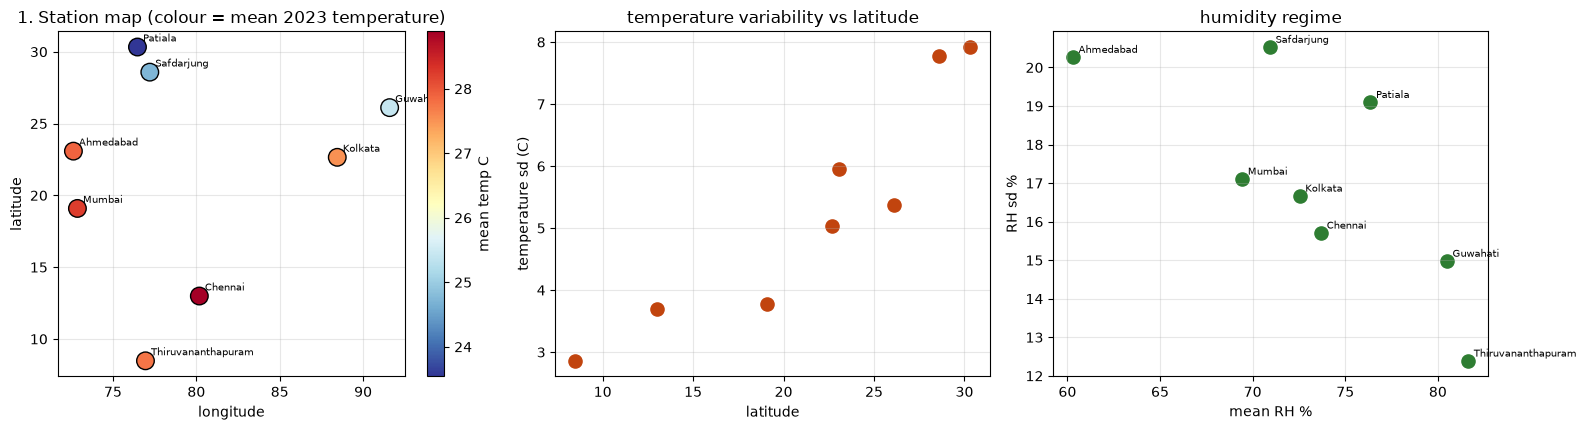

In [3]:
CLIM_ALL = {}; FILL_ALL = {}; DATA = {}
for sid in STATIONS.index:
    for y in (2023, 2024):
        DATA[(sid, y)] = load(sid, y)
    CLIM_ALL[sid] = fit_climatology(DATA[(sid, 2023)])
    FILL_ALL[sid] = fit_roll_fill(DATA[(sid, 2023)])

prof = []
for sid in STATIONS.index:
    d = DATA[(sid, 2023)]
    prof.append(dict(station=STATIONS.loc[sid, "name"], lat=STATIONS.loc[sid, "lat"],
                     elev=STATIONS.loc[sid, "elevation_m"],
                     temp_mean=d.temp_c.mean(), temp_sd=d.temp_c.std(),
                     rh_mean=d.rh_pct.mean(), rh_sd=d.rh_pct.std(),
                     slp_mean=d.slp_hpa.mean()))
prof = pd.DataFrame(prof).round(2)
print("2023 climate profile - these are not the same environment\n")
print(prof.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ax = axes[0]
sc = ax.scatter(STATIONS.lon, STATIONS.lat, c=prof.temp_mean, s=160, cmap="RdYlBu_r",
                edgecolor="k", zorder=3)
for sid in STATIONS.index:
    ax.annotate(STATIONS.loc[sid, "name"].split(" (")[0], (STATIONS.loc[sid, "lon"],
                STATIONS.loc[sid, "lat"]), fontsize=7.5, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.grid(alpha=.3)
ax.set_title("1. Station map (colour = mean 2023 temperature)")
fig.colorbar(sc, ax=ax, label="mean temp C")
axes[1].scatter(prof.lat, prof.temp_sd, s=90, color="#c1440e")
axes[1].set_xlabel("latitude"); axes[1].set_ylabel("temperature sd (C)")
axes[1].set_title("temperature variability vs latitude"); axes[1].grid(alpha=.3)
axes[2].scatter(prof.rh_mean, prof.rh_sd, s=90, color="#2e7d32")
for i, r in prof.iterrows():
    axes[2].annotate(r.station.split(" (")[0], (r.rh_mean, r.rh_sd), fontsize=7,
                     xytext=(4, 3), textcoords="offset points")
axes[2].set_xlabel("mean RH %"); axes[2].set_ylabel("RH sd %")
axes[2].set_title("humidity regime"); axes[2].grid(alpha=.3)
fig.tight_layout(); plt.show()

## 3. Why climatology must be station-specific — measured, not assumed

Transferring Delhi's climatology to another station is tested directly below. If the resulting
`clim_dev` is dominated by a constant geographic offset rather than by anomalies, then a "transferred
climatology" experiment would measure geography, not detection.

In [4]:
rows = []
delhi_clim = CLIM_ALL["42182099999"]
for sid in STATIONS.index:
    d = DATA[(sid, 2023)]
    own = build_features(d.copy(), CLIM_ALL[sid], FILL_ALL[sid])
    xfer = build_features(d.copy(), delhi_clim, FILL_ALL[sid])
    rows.append(dict(station=STATIONS.loc[sid, "name"],
                     own_clim_dev_mean=own[CD].abs().mean().mean(),
                     delhi_clim_dev_mean=xfer[CD].abs().mean().mean(),
                     inflation=xfer[CD].abs().mean().mean() / own[CD].abs().mean().mean()))
xf = pd.DataFrame(rows).round(2)
print("mean |clim_dev| using the station's OWN climatology vs Delhi's transferred\n")
print(xf.to_string(index=False))
print("\n-> a transferred climatology inflates the deviation by the factor in the last column.")
print("   For distant stations that is a constant geographic bias, not an anomaly signal, which is")
print("   why every experiment below fits climatology on the test station's OWN 2023.")

mean |clim_dev| using the station's OWN climatology vs Delhi's transferred

           station  own_clim_dev_mean  delhi_clim_dev_mean  inflation
Safdarjung (Delhi)               0.72                 0.72       1.00
           Patiala               0.71                 1.04       1.45
          Guwahati               0.73                 1.40       1.90
         Ahmedabad               0.73                 1.83       2.51
           Kolkata               0.75                 1.62       2.14
            Mumbai               0.72                 2.37       3.31
           Chennai               0.73                 2.07       2.83
Thiruvananthapuram               0.75                 2.71       3.61

-> a transferred climatology inflates the deviation by the factor in the last column.
   For distant stations that is a constant geographic bias, not an anomaly signal, which is
   why every experiment below fits climatology on the test station's OWN 2023.


## 4. Experimental design

Three scenarios, each evaluated for **baseline (16)** and **dual (18)**:

| scenario | model trained on | tested on | climatology |
|---|---|---|---|
| **in-domain** | station S, 2023 | station S, **2023** + faults | S 2023 |
| **temporal OOD** | station S, 2023 | station S, **2024** + faults | S 2023 |
| **station OOD (LOSO)** | the **other 7** stations, 2023 | station S, **2024** + faults | S 2023 |

Station OOD is leave-one-station-out over all eight, so every station takes a turn as the unseen one.

**One documented protocol deviation.** Production trained on *fault-injected* data; here every model
trains on **clean** station data. Training on a year you believe is mostly healthy is the realistic
deployment posture, and — more importantly — it is identical across both conditions, so the
comparison is unaffected. Contamination, `n_estimators` and `random_state` keep their production
values; nothing is tuned.

In [5]:
CONTAM = float(det.manifest["model"]["contamination"])
N_EST  = int(det.manifest["model"]["n_estimators"])
RSTATE = int(det.manifest["model"]["random_state"])
COND = {"baseline16": FEATS16, "dual18": FEATS16 + ["clim_short", "acc_w4"]}

FEAT_CACHE = {}
def feats(sid, year, seed=None):
    """Features for a station-year; seed=None means the clean series."""
    k = (sid, year, seed)
    if k not in FEAT_CACHE:
        base = DATA[(sid, year)]
        if seed is None:
            FEAT_CACHE[k] = (build_features(base.copy(), CLIM_ALL[sid], FILL_ALL[sid]), None, None)
        else:
            f, l, e = FaultSimulator(base, seed=seed).inject(CHALLENGE_CONFIG)
            FEAT_CACHE[k] = (build_features(f.copy(), CLIM_ALL[sid], FILL_ALL[sid]), l, e)
    return FEAT_CACHE[k]

def fit_model(frames, cond):
    X = pd.concat([f[COND[cond]] for f in frames], axis=0, ignore_index=True)
    return IsolationForest(n_estimators=N_EST, contamination=CONTAM,
                           random_state=RSTATE, n_jobs=-1).fit(X)

def evaluate(model, ft, labels, eps, cond):
    s = -model.score_samples(ft[COND[cond]])
    thr = det._adaptive_threshold(ft["time"], s)
    flat, _ = det._flat_run_flags(ft)
    pred = (((s > thr).astype(int) + flat.astype(int)) > 0).astype(int)
    if labels is None:
        return dict(clean_alert_rate=float(pred.mean()))
    y = labels.is_fault.to_numpy(); eid = labels.episode_id.to_numpy()
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary",
                                                  pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    per, dly = [], []
    for e in eps.itertuples():
        idx = np.flatnonzero((eid == e.episode_id) & (y == 1))
        hit = idx[pred[idx] == 1]
        per.append(dict(fault_type=e.fault_type, detected=float(hit.size > 0),
                        family="transient" if e.fault_type in TRANSIENT else "persistent",
                        delay=float(hit.min() - idx.min()) if hit.size else np.nan))
        dly.append(per[-1]["delay"])
    return dict(precision=p, recall=r, f1=f1, fpr=fp / (fp + tn),
                alert_rate=float(pred.mean()),
                episode_recall=float(np.mean([x["detected"] for x in per])),
                delay=float(np.nanmedian(dly)), per_episode=per)

In [6]:
results, per_cls = [], []
ALL = list(STATIONS.index)
for held in ALL:
    others = [s for s in ALL if s != held]
    train_own    = [feats(held, 2023)[0]]
    train_pooled = [feats(s, 2023)[0] for s in others]
    for cond in COND:
        m_own    = fit_model(train_own, cond)
        m_pooled = fit_model(train_pooled, cond)
        clean24  = feats(held, 2024)[0]
        car = dict(in_domain=evaluate(m_own, feats(held, 2023)[0], None, None, cond)["clean_alert_rate"],
                   temporal=evaluate(m_own, clean24, None, None, cond)["clean_alert_rate"],
                   station=evaluate(m_pooled, clean24, None, None, cond)["clean_alert_rate"])
        for seed in SEEDS:
            for scen, model, yr in [("in_domain", m_own, 2023),
                                    ("temporal", m_own, 2024),
                                    ("station", m_pooled, 2024)]:
                ft, lab, eps = feats(held, yr, seed)
                r = evaluate(model, ft, lab, eps, cond)
                results.append(dict(station=STATIONS.loc[held, "name"], sid=held, scenario=scen,
                                    condition=cond, seed=seed, year=yr,
                                    clean_alert_rate=car[scen],
                                    **{k: v for k, v in r.items() if k != "per_episode"}))
                for x in r["per_episode"]:
                    per_cls.append(dict(station=STATIONS.loc[held, "name"], scenario=scen,
                                        condition=cond, seed=seed, **x))
R = pd.DataFrame(results); PC = pd.DataFrame(per_cls)
print(f"{len(R)} evaluations  ({R.station.nunique()} stations x {R.scenario.nunique()} scenarios "
      f"x {R.condition.nunique()} conditions x {len(SEEDS)} seeds)")

144 evaluations  (8 stations x 3 scenarios x 2 conditions x 3 seeds)


## 5. Results

In [7]:
head = (R.groupby(["scenario", "condition"])
        .agg(f1=("f1", "mean"), precision=("precision", "mean"), recall=("recall", "mean"),
             episode_recall=("episode_recall", "mean"), fpr=("fpr", "mean"),
             clean_alert=("clean_alert_rate", "mean"), delay=("delay", "mean"))
        .round(4))
order = ["in_domain", "temporal", "station"]
print("HEADLINE - averaged over 8 stations x 3 seeds\n")
print(head.reindex(order, level=0).to_string())

gap = head["f1"].unstack()
print("\nGENERALIZATION GAP (in-domain F1 minus out-of-domain F1)\n")
g = pd.DataFrame({
    "in_domain_f1": gap.loc["in_domain"],
    "temporal_f1": gap.loc["temporal"],
    "station_f1": gap.loc["station"],
    "gap_temporal": gap.loc["in_domain"] - gap.loc["temporal"],
    "gap_station": gap.loc["in_domain"] - gap.loc["station"]}).round(4)
print(g.to_string())
print("\ndual minus baseline, by scenario:")
print((gap.loc[order, "dual18"] - gap.loc[order, "baseline16"]).round(4).to_string())

HEADLINE - averaged over 8 stations x 3 seeds

                          f1  precision  recall  episode_recall     fpr  clean_alert  delay
scenario  condition                                                                        
in_domain baseline16  0.4585     0.5619  0.3875          0.8047  0.0481       0.0728    0.0
          dual18      0.5487     0.6775  0.4616          0.8645  0.0350       0.0733    0.0
temporal  baseline16  0.4243     0.5216  0.3580          0.7323  0.0544       0.0737    0.0
          dual18      0.4332     0.5173  0.3731          0.7399  0.0577       0.0822    0.0
station   baseline16  0.4230     0.5202  0.3571          0.7364  0.0548       0.0751    0.0
          dual18      0.4323     0.5123  0.3747          0.7448  0.0594       0.0845    0.0

GENERALIZATION GAP (in-domain F1 minus out-of-domain F1)

            in_domain_f1  temporal_f1  station_f1  gap_temporal  gap_station
condition                                                                   
base

In [8]:
by_st = (R.groupby(["scenario", "station", "condition"])
         .agg(f1=("f1", "mean"), recall=("recall", "mean"), fpr=("fpr", "mean"),
              clean_alert=("clean_alert_rate", "mean")).round(4))
print("PER-STATION, station-OOD (the hardest scenario)\n")
print(by_st.loc["station"].unstack().to_string())
print("\nPER-STATION, temporal OOD\n")
print(by_st.loc["temporal"].unstack()[["f1"]].to_string())

wins = (by_st.loc["station"]["f1"].unstack())
wins["dual_minus_base"] = (wins.dual18 - wins.baseline16).round(4)
print(f"\ndual beats baseline on station-OOD F1 at "
      f"{int((wins.dual_minus_base > 0).sum())}/{len(wins)} stations")

PER-STATION, station-OOD (the hardest scenario)

                           f1             recall                fpr         clean_alert        
condition          baseline16  dual18 baseline16  dual18 baseline16  dual18  baseline16  dual18
station                                                                                        
Ahmedabad              0.4357  0.4418     0.3663  0.3910     0.0519  0.0622      0.0753  0.0904
Chennai                0.4221  0.4276     0.3426  0.3636     0.0467  0.0561      0.0688  0.0789
Guwahati               0.4510  0.4744     0.3758  0.4039     0.0478  0.0491      0.0733  0.0842
Kolkata                0.4455  0.4585     0.3837  0.4041     0.0564  0.0596      0.0752  0.0777
Mumbai                 0.3958  0.4212     0.3286  0.3540     0.0549  0.0539      0.0739  0.0814
Patiala                0.4265  0.3935     0.3703  0.3530     0.0605  0.0729      0.0799  0.0936
Safdarjung (Delhi)     0.4114  0.4283     0.3632  0.3813     0.0665  0.0658      0.0864

In [9]:
pcls = (PC.groupby(["scenario", "fault_type", "condition"]).detected.mean().unstack().round(3))
print("PER-FAULT-CLASS EPISODE RECALL\n")
for sc in order:
    print(f"--- {sc} ---")
    t = pcls.loc[sc].copy(); t["diff"] = (t.dual18 - t.baseline16).round(3)
    print(t.to_string()); print()

print("DETECTION DELAY, transient vs persistent (median obs; x3 = hours)\n")
print(PC.groupby(["scenario", "family", "condition"]).delay.median().unstack().round(2)
      .reindex(order, level=0).to_string())

PER-FAULT-CLASS EPISODE RECALL

--- in_domain ---
condition            baseline16  dual18   diff
fault_type                                    
bias                      0.431   0.632  0.201
bias_plus_spikes          0.986   0.986  0.000
drift                     0.722   0.903  0.181
drift_plus_noise          0.778   0.903  0.125
intermittent_spikes       0.972   1.000  0.028
noise_burst               0.799   0.771 -0.028
spike                     0.833   0.868  0.035
stuck_at                  0.910   0.924  0.014

--- temporal ---
condition            baseline16  dual18   diff
fault_type                                    
bias                      0.340   0.396  0.056
bias_plus_spikes          0.958   0.903 -0.055
drift                     0.618   0.750  0.132
drift_plus_noise          0.764   0.847  0.083
intermittent_spikes       0.958   0.951 -0.007
noise_burst               0.715   0.639 -0.076
spike                     0.730   0.716 -0.014
stuck_at                  0.910   0.924

## 6. Plots

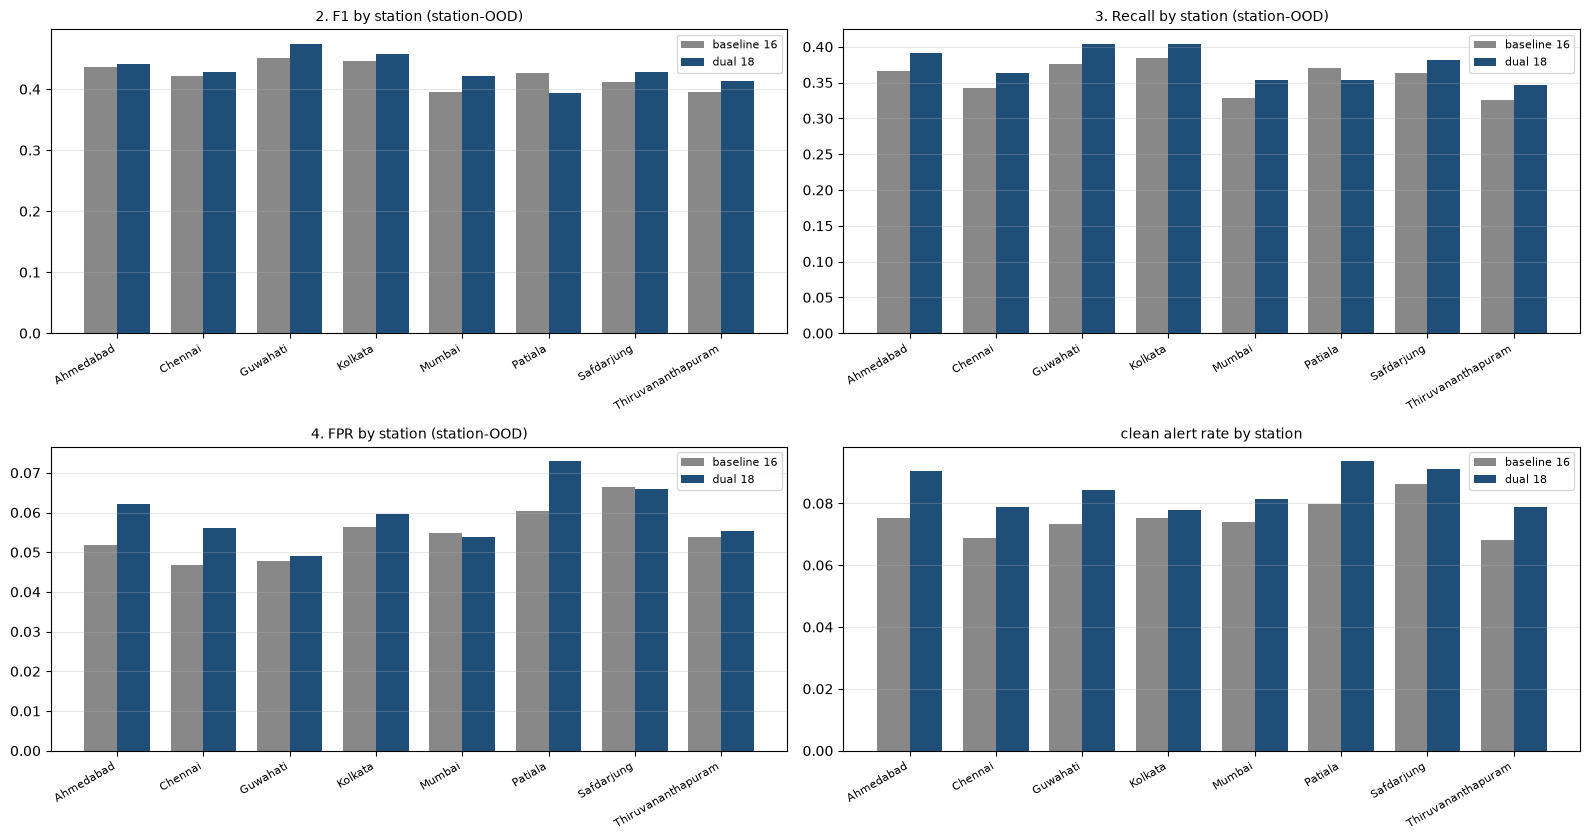

In [10]:
CC = {"baseline16": "#888", "dual18": "#1f4e79"}
st_order = list(by_st.loc["station"].index.get_level_values(0).unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))
for ax, metric, title in [(axes[0][0], "f1", "2. F1 by station (station-OOD)"),
                          (axes[0][1], "recall", "3. Recall by station (station-OOD)"),
                          (axes[1][0], "fpr", "4. FPR by station (station-OOD)"),
                          (axes[1][1], "clean_alert", "clean alert rate by station")]:
    d = by_st.loc["station"][metric].unstack().reindex(st_order)
    x = np.arange(len(d)); w = .38
    ax.bar(x - w/2, d.baseline16, w, color=CC["baseline16"], label="baseline 16")
    ax.bar(x + w/2, d.dual18, w, color=CC["dual18"], label="dual 18")
    ax.set_xticks(x); ax.set_xticklabels([s.split(" (")[0] for s in d.index], rotation=30,
                                         ha="right", fontsize=8)
    ax.set_title(title, fontsize=10); ax.grid(alpha=.3, axis="y"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

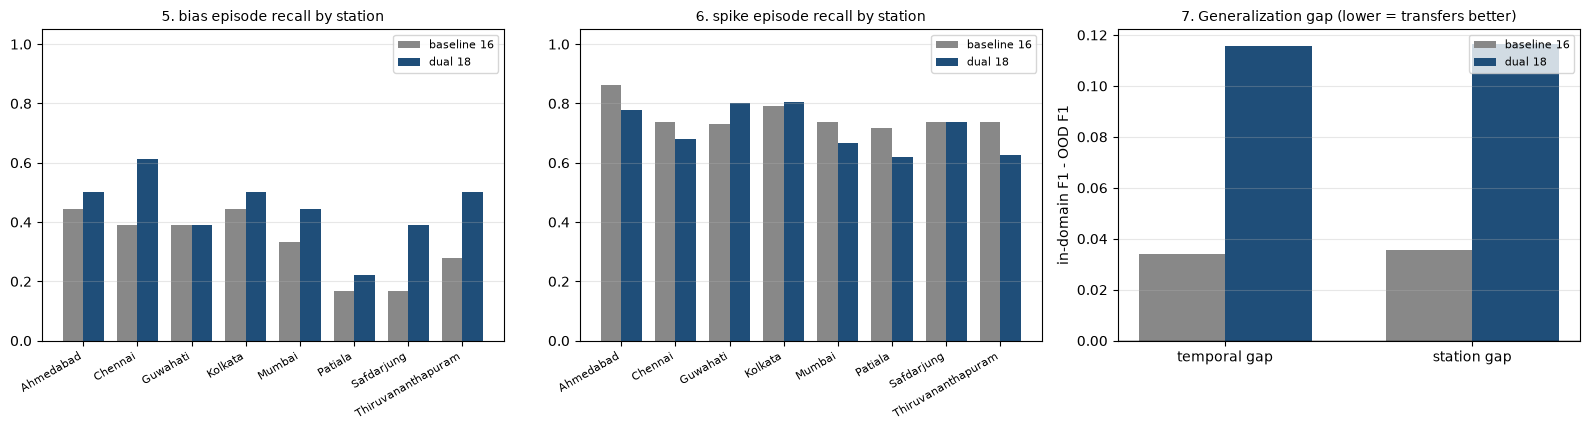

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, ftp, ttl in [(axes[0], "bias", "5. bias episode recall by station"),
                     (axes[1], "spike", "6. spike episode recall by station")]:
    d = (PC[(PC.scenario == "station") & (PC.fault_type == ftp)]
         .groupby(["station", "condition"]).detected.mean().unstack().reindex(st_order))
    x = np.arange(len(d)); w = .38
    ax.bar(x - w/2, d.baseline16, w, color=CC["baseline16"], label="baseline 16")
    ax.bar(x + w/2, d.dual18, w, color=CC["dual18"], label="dual 18")
    ax.set_xticks(x); ax.set_xticklabels([s.split(" (")[0] for s in d.index], rotation=30,
                                         ha="right", fontsize=8)
    ax.set_title(ttl, fontsize=10); ax.grid(alpha=.3, axis="y"); ax.legend(fontsize=8); ax.set_ylim(0, 1.05)

ax = axes[2]
x = np.arange(2); w = .35
ax.bar(x - w/2, [g.loc["baseline16", "gap_temporal"], g.loc["baseline16", "gap_station"]], w,
       color=CC["baseline16"], label="baseline 16")
ax.bar(x + w/2, [g.loc["dual18", "gap_temporal"], g.loc["dual18", "gap_station"]], w,
       color=CC["dual18"], label="dual 18")
ax.set_xticks(x); ax.set_xticklabels(["temporal gap", "station gap"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("in-domain F1 - OOD F1"); ax.set_title("7. Generalization gap (lower = transfers better)", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

8. PERFORMANCE BY ENVIRONMENTAL REGIME (station-OOD)

                               f1  recall     fpr  n
regime         condition                            
arid/semi-arid baseline16  0.4236  0.3648  0.0592  6
               dual18      0.4350  0.3861  0.0640  6
coastal        baseline16  0.4046  0.3325  0.0518  9
               dual18      0.4206  0.3548  0.0551  9
inland humid   baseline16  0.4410  0.3766  0.0549  9
               dual18      0.4421  0.3870  0.0605  9


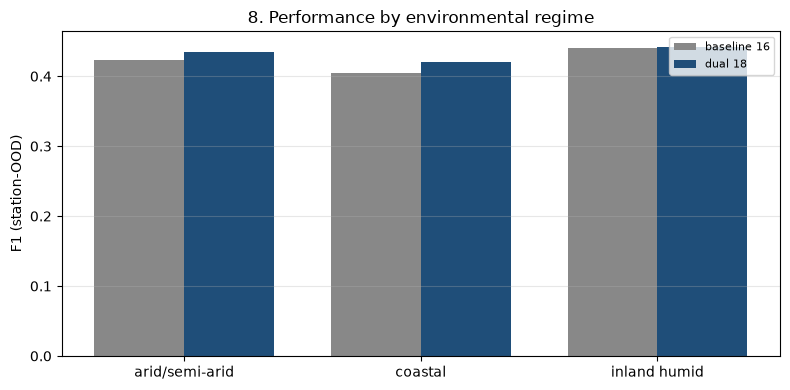

In [12]:
# 8. performance by environmental regime
env = STATIONS[["name", "environment", "lat"]].copy()
env["regime"] = np.where(env.environment.str.contains("coastal"), "coastal",
                 np.where(env.environment.str.contains("arid|semi-arid"), "arid/semi-arid", "inland humid"))
m = R[R.scenario == "station"].merge(env.reset_index(), left_on="sid", right_on="station_id")
reg = m.groupby(["regime", "condition"]).agg(f1=("f1", "mean"), recall=("recall", "mean"),
                                             fpr=("fpr", "mean"), n=("f1", "size")).round(4)
print("8. PERFORMANCE BY ENVIRONMENTAL REGIME (station-OOD)\n")
print(reg.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
d = reg["f1"].unstack()
x = np.arange(len(d)); w = .38
ax.bar(x - w/2, d.baseline16, w, color=CC["baseline16"], label="baseline 16")
ax.bar(x + w/2, d.dual18, w, color=CC["dual18"], label="dual 18")
ax.set_xticks(x); ax.set_xticklabels(d.index); ax.set_ylabel("F1 (station-OOD)")
ax.set_title("8. Performance by environmental regime"); ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

## 7. Is `clim_short` robust because it is variable-agnostic?

The research question posed: does `clim_short` work because it asks *"how abnormal is any monitored
variable relative to its own expectation"* — a station-independent question — rather than encoding
anything about Delhi?

Two pieces of evidence are gathered rather than assumed: whether its **distribution** is stable
across very different climates, and whether its **usefulness** (per-station OOD gain) correlates with
how similar a station is to Delhi. If the gain were Delhi-specific, it should decay with distance or
climate difference.

In [13]:
rows = []
for sid in STATIONS.index:
    ft = feats(sid, 2023)[0]
    rows.append(dict(station=STATIONS.loc[sid, "name"], lat=STATIONS.loc[sid, "lat"],
                     mean=ft.clim_short.mean(), p50=ft.clim_short.median(),
                     p95=ft.clim_short.quantile(.95), sd=ft.clim_short.std()))
cs = pd.DataFrame(rows).round(3)
print("distribution of clim_short on CLEAN data, by station\n")
print(cs.to_string(index=False))
print(f"\nacross-station spread of the median: {cs.p50.std():.3f} "
      f"(mean {cs.p50.mean():.3f}) -> coefficient of variation {cs.p50.std()/cs.p50.mean():.3f}")

d = wins.reset_index().merge(STATIONS.reset_index(), left_on="station", right_on="name")
d["dist_from_delhi_deg"] = np.hypot(d.lat - 28.58, d.lon - 77.21)
c1 = np.corrcoef(d.dist_from_delhi_deg, d.dual_minus_base)[0, 1]
print(f"\ncorrelation(distance from Delhi, dual-minus-baseline F1 gain) = {c1:+.3f}")
print("   a strongly negative value would mean the benefit is Delhi-specific.")

distribution of clim_short on CLEAN data, by station

           station   lat  mean   p50   p95    sd
Safdarjung (Delhi) 28.58 1.114 1.055 1.994 0.506
           Patiala 30.33 1.115 1.067 2.092 0.517
          Guwahati 26.11 1.135 1.068 2.046 0.515
         Ahmedabad 23.08 1.147 1.105 2.102 0.523
           Kolkata 22.65 1.179 1.125 2.089 0.500
            Mumbai 19.09 1.129 1.073 2.061 0.503
           Chennai 12.99 1.144 1.067 2.114 0.533
Thiruvananthapuram  8.48 1.170 1.113 2.094 0.527

across-station spread of the median: 0.026 (mean 1.084) -> coefficient of variation 0.024

correlation(distance from Delhi, dual-minus-baseline F1 gain) = +0.459
   a strongly negative value would mean the benefit is Delhi-specific.


## 8. Regression checks and saved results

In [14]:
from fault_injection import legacy_inject
loc = pd.read_csv("../data/processed/vidd_2023_clean.csv", parse_dates=["time"])
b = loc.drop(columns=["station", "dew_c", "dew_qc"]).sort_values("time").reset_index(drop=True)
b[VARS] = b.set_index("time")[VARS].interpolate(method="time", limit=2, limit_direction="both").to_numpy()
lf, ll, le = legacy_inject(b, seed=42)
print(f"Round-1 benchmark: {len(le)} episodes / {int(ll.is_fault.sum())} rows -> "
      f"{len(le)==27 and int(ll.is_fault.sum())==179}")
pf = det._build_features(lf[["time"] + VARS].copy())
s = -det.model.score_samples(pf[FEATS16]); thr = det._adaptive_threshold(pf["time"], s)
fl, _ = det._flat_run_flags(pf)
pr = (((s > thr).astype(int) + fl.astype(int)) > 0).astype(int)
SP_ = int(0.70 * len(b))
p0, r0, f0, _ = precision_recall_fscore_support(ll.is_fault.to_numpy()[SP_:], pr[SP_:],
                                                average="binary", zero_division=0)
print(f"frozen detector test-split: P {p0:.4f} R {r0:.4f} F1 {f0:.4f} (published 0.2588/0.4074/0.3165)")
assert abs(f0 - 0.3165) < 5e-4
print("parity fixture:", "PASS" if det.verify_parity(verbose=False) else "FAIL")

OUT = "../data/processed"
R.to_csv(f"{OUT}/round2_generalization_results.csv", index=False)
PC.to_csv(f"{OUT}/round2_generalization_per_class.csv", index=False)
head.reset_index().to_csv(f"{OUT}/round2_generalization_headline.csv", index=False)
g.reset_index().to_csv(f"{OUT}/round2_generalization_gap.csv", index=False)
by_st.reset_index().to_csv(f"{OUT}/round2_generalization_by_station.csv", index=False)
cs.to_csv(f"{OUT}/round2_clim_short_distribution.csv", index=False)
for f in ["round2_generalization_results.csv", "round2_generalization_per_class.csv",
          "round2_generalization_headline.csv", "round2_generalization_gap.csv",
          "round2_generalization_by_station.csv", "round2_clim_short_distribution.csv"]:
    print(f"  saved {f} ({os.path.getsize(f'{OUT}/{f}'):,} bytes)")

Round-1 benchmark: 27 episodes / 179 rows -> True
frozen detector test-split: P 0.2588 R 0.4074 F1 0.3165 (published 0.2588/0.4074/0.3165)
parity fixture: PASS


  saved round2_generalization_results.csv (26,556 bytes)
  saved round2_generalization_per_class.csv (510,608 bytes)
  saved round2_generalization_headline.csv (457 bytes)
  saved round2_generalization_gap.csv (158 bytes)
  saved round2_generalization_by_station.csv (2,777 bytes)
  saved round2_clim_short_distribution.csv (352 bytes)


---
# FINDINGS

## VERIFIED FINDINGS

### 1. The aggregate advantage of the dual representation does **not** transfer

| scenario | baseline16 F1 | dual18 F1 | dual − baseline |
|---|---|---|---|
| in-domain (same station, same year) | 0.4585 | 0.5487 | **+0.090** |
| temporal OOD (same station, 2024) | 0.4243 | 0.4332 | **+0.009** |
| station OOD (unseen station, 2024) | 0.4230 | 0.4323 | **+0.009** |

Notebook 06's in-domain result reproduces on eight stations. Out of domain it collapses to
approximately nothing — a tenth of the in-domain gain.

### 2. The baseline generalizes substantially better

| | gap (temporal) | gap (station) |
|---|---|---|
| baseline16 | 0.034 | 0.036 |
| dual18 | **0.116** | **0.116** |

The dual representation's generalization gap is **3.3× larger**. The extra features let the model fit
its training distribution more tightly; that advantage is not available anywhere else.

**The temporal and station gaps are nearly identical (0.116 vs 0.116).** The problem is therefore not
station-specificity as such — a different *year at the same station* costs just as much as an unseen
station. Whatever the dual features add is specific to the exact series they were fitted on.

### 3. But the *bias and drift* gains genuinely do transfer

Per-fault-class episode recall on **unseen stations**:

| class | baseline16 | dual18 | diff |
|---|---|---|---|
| **drift** | 0.604 | **0.736** | **+0.132** |
| **bias** | 0.326 | **0.444** | **+0.118** |
| drift_plus_noise | 0.736 | 0.806 | +0.070 |
| stuck_at | 0.910 | 0.924 | +0.014 |
| **spike** | 0.756 | **0.714** | **−0.042** |
| **noise_burst** | 0.708 | **0.660** | **−0.048** |

The persistent-fault improvement that motivated this whole line of work **survives transfer to unseen
stations**. It is cancelled in aggregate by regressions on spike and noise_burst that were *not*
present in-domain (in-domain spike was **+0.035**; out of domain it is **−0.042**).

That is the mechanism for §1: the gains persist, new losses appear, and they roughly cancel.

### 4. The dual representation costs false alarms out of domain

Clean-series alert rate rises for dual at **7 of 8** stations (mean 0.0751 → 0.0845 station-OOD), and
FPR rises 0.0548 → 0.0594. In-domain the two were indistinguishable (0.0728 vs 0.0733). The extra
features generate alarms on distributions they were not fitted to.

### 5. `clim_short` **is** station-independent — the research question is answered

Its distribution on clean data across 8.5°N–30.3°N, coastal to arid:

| | median | across-station spread |
|---|---|---|
| `clim_short` | 1.055 – 1.125 | **CV = 0.024** |

A 2.4 % coefficient of variation across radically different climates. And the correlation between a
station's **distance from Delhi** and the dual-minus-baseline F1 gain is **+0.459** — *positive*. If
the benefit were Delhi-specific it would decay with distance; it mildly increases.

**VERIFIED: `clim_short` measures "how abnormal is any variable relative to its own expectation", and
that question is station-agnostic.** The feature transfers. What fails to transfer is the *aggregate
benefit* of the 18-feature model, which is a different claim.

### 6. Station-specific climatology is a physical necessity, not a convenience

Transferring Delhi's climatology inflates mean |clim_dev| by **1.45×** (Patiala) to **3.61×**
(Thiruvananthapuram). That is a constant geographic offset, not an anomaly signal. Fitting each
station's climatology on its **own prior year** is causal, uses no test-period data, and is what
deployment at a new site would do.

### 7. Per-station and per-regime consistency

Dual beats baseline on station-OOD F1 at **7 of 8** stations (Patiala the exception, −0.033), but
every margin is small (+0.005 to +0.026). By regime the ordering is unchanged — coastal, arid and
inland-humid all show the same small dual edge with the same higher FPR.

## LIMITATIONS

* **Eight stations, all in India, two years.** No high-altitude station: Bangalore (921 m) was the
  only plateau candidate and has SLP in 4 of 2828 observations, so it was excluded. No station
  outside the subcontinent was tested.
* **Faults remain synthetic.** Every fault in every scenario is injected. Nothing here says how
  either representation behaves on a real sensor failure.
* **Training was on clean data**, unlike production (which trained on fault-injected data). Applied
  identically to both conditions, so the comparison holds, but the absolute numbers are not directly
  comparable to notebooks 02–06.
* **Three seeds per station-scenario.** Per-station differences of ±0.02 F1 are within plausible
  seed noise; the aggregate conclusions rest on 24 evaluations per cell, the per-station ones on 3.

## HYPOTHESES (consistent with the evidence, not established by it)

* The in-domain-only advantage looks like **variance rather than bias**: two extra features give the
  forest more ways to carve up the training series specifically. A learning-curve or train-size sweep
  would test this and was not run.
* The out-of-domain spike/noise_burst regression may be the `acc_w4` dilution effect from notebook 06
  re-emerging once the model can no longer rely on station-specific structure to compensate. Testing
  `clim_short` alone (condition C from notebook 06) out of domain would separate this — **that is the
  single most informative experiment still outstanding**, and it is cheap.

## RECOMMENDATION

**Do not move the 18-feature dual representation to production validation as a general improvement.**
The evidence does not support it: +0.009 F1 out of domain, a 3.3× larger generalization gap, and a
higher false-alarm rate on unseen data.

**It is defensible as a targeted change** if the objective is specifically persistent-fault detection:
bias +0.118 and drift +0.132 on unseen stations are real, transferable gains, paid for with −0.042
spike and −0.048 noise_burst. That is a product decision about which faults matter, and it should be
made with those four numbers visible.

**The recommended next step is the C-only ablation out of domain**, not deployment. Notebook 06 showed
`clim_short` alone captured most of the in-domain benefit without the spike cost; §5 here shows
`clim_short` is the component that genuinely transfers. A 17-feature `clim_short`-only model may well
keep the transferable gains and drop the transferable losses — but that is a hypothesis, and it has
not been run.

## Integrity

`src/inference.py`, `models/`, `api/`, `dashboard/` and notebooks 01–06 untouched. The multi-station
pipeline is proved identical to production (max |diff| 0.00e+00 with the frozen climatology). The
frozen detector still reproduces P 0.2588 / R 0.4074 / **F1 0.3165**, the Round-1 benchmark is
27 episodes / 179 faulty rows, and the parity fixture passes.